In [25]:
import requests
from google.colab import userdata

api_key = userdata.get('OPENROUTER_API_KEY')

response = requests.post(
    "https://openrouter.ai/api/v1/embeddings",
    headers={
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    },
    json={
        "model": "openai/text-embedding-3-small",
        "input": "The quick brown fox jumps over the lazy dog"
    }
)

response.raise_for_status()

data = response.json()
embedding = data["data"][0]["embedding"]
print(f"Embedding dimension: {len(embedding)}")

Embedding dimension: 1536


In [23]:
import requests
from google.colab import userdata

api_key = userdata.get('OPENROUTER_API_KEY')

response = requests.post(
    "https://openrouter.ai/api/v1/embeddings",
    headers={
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    },
    json={
        "model": "openai/text-embedding-3-small",
        "input": [
            "Machine learning is a subset of artificial intelligence",
            "Deep learning uses neural networks with multiple layers",
            "Natural language processing enables computers to understand text"
        ]
    }
)

response.raise_for_status()
data = response.json()

for i, item in enumerate(data["data"]):
    print(f"Embedding {i}: {len(item['embedding'])} dimensões")

Embedding 0: 1536 dimensões
Embedding 1: 1536 dimensões
Embedding 2: 1536 dimensões


In [28]:
import requests
import numpy as np
from google.colab import userdata

OPENROUTER_API_KEY = userdata.get('OPENROUTER_API_KEY')

documents = [
    "The cat sat on the mat",
    "Dogs are loyal companions",
    "Python is a programming language",
    "Machine learning models require training data",
    "The weather is sunny today"
]

def cosine_similarity(a, b):
    """Calculate cosine similarity between two vectors"""
    dot_product = np.dot(a, b)
    magnitude_a = np.linalg.norm(a)
    magnitude_b = np.linalg.norm(b)
    return dot_product / (magnitude_a * magnitude_b)

def semantic_search(query, documents):
    """Perform semantic search using embeddings"""
    response = requests.post(
        "https://openrouter.ai/api/v1/embeddings",
        headers={
            "Authorization": f"Bearer {OPENROUTER_API_KEY}",
            "Content-Type": "application/json",
        },
        json={
            "model": "openai/text-embedding-3-small",
            "input": [query] + documents
        }
    )

    response.raise_for_status()

    data = response.json()
    query_embedding = np.array(data["data"][0]["embedding"])
    doc_embeddings = [np.array(item["embedding"]) for item in data["data"][1:]]

    results = []
    for i, doc in enumerate(documents):
        similarity = cosine_similarity(query_embedding, doc_embeddings[i])
        results.append({"document": doc, "similarity": float(similarity)})

    results.sort(key=lambda x: x["similarity"], reverse=True)

    return results

results = semantic_search("pets and animals", documents)
print("Search results:")
for i, result in enumerate(results):
    print(f"{i + 1}. {result['document']} (similarity: {result['similarity']:.4f})")

Search results:
1. Dogs are loyal companions (similarity: 0.4183)
2. The cat sat on the mat (similarity: 0.3531)
3. Python is a programming language (similarity: 0.1502)
4. Machine learning models require training data (similarity: 0.1329)
5. The weather is sunny today (similarity: 0.1197)


In [34]:
pip install requests numpy matplotlib scikit-learn

Obtendo embeddings da API...
Embeddings obtidos. Matriz original: (9, 1536)
Reduzindo dimensões com PCA...
Nova matriz 2D: (9, 2)


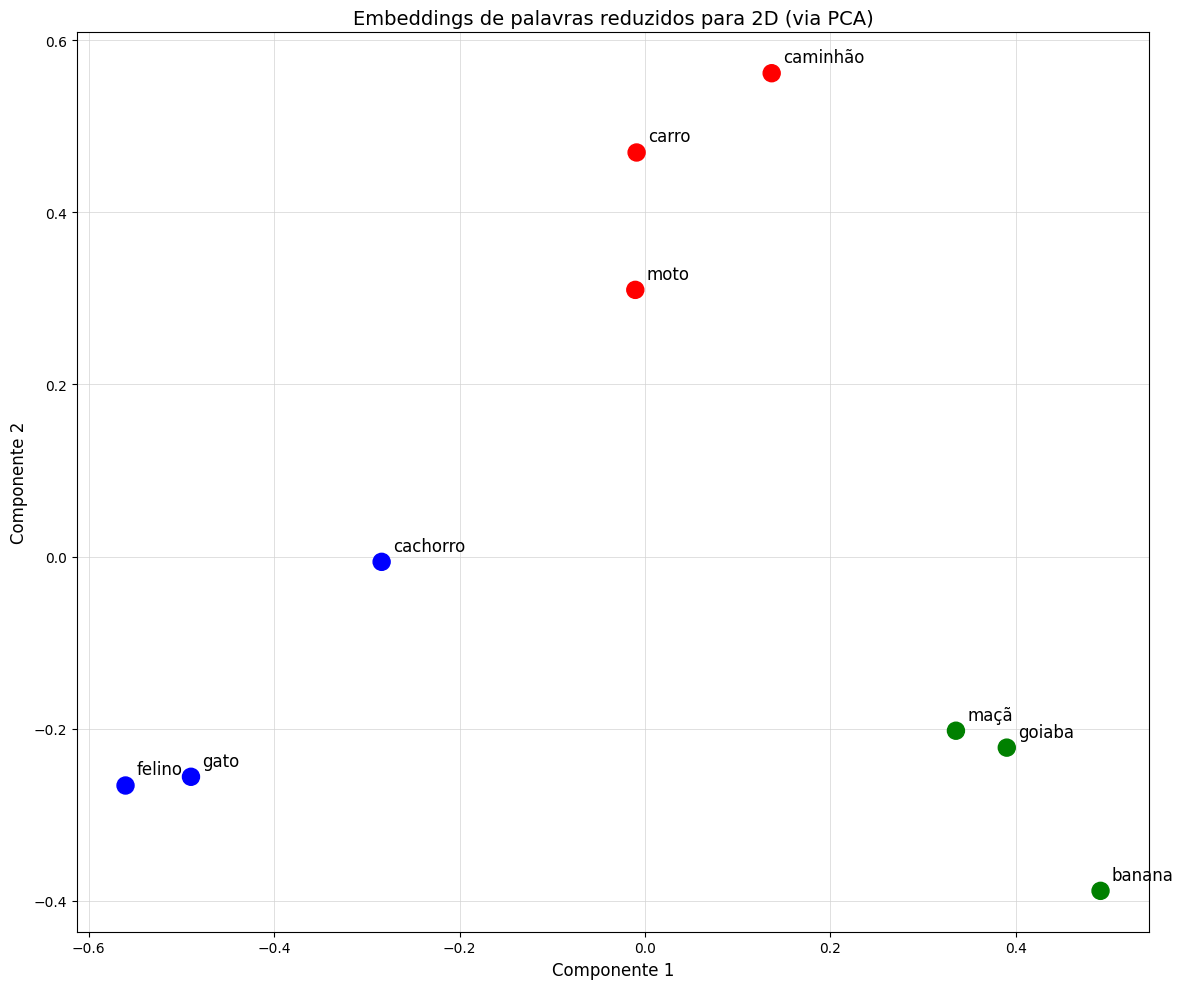

In [35]:
import requests
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from google.colab import userdata

try:
    OPENROUTER_API_KEY = userdata.get('OPENROUTER_API_KEY')

if not OPENROUTER_API_KEY or OPENROUTER_API_KEY == "SUA_CHAVE_API_AQUI":
    raise ValueError("Você precisa configurar sua OPENROUTER_API_KEY.")

data_info = [
    ("gato", "blue"), ("felino", "blue"), ("cachorro", "blue"),
    ("carro", "red"), ("caminhão", "red"), ("moto", "red"),
    ("banana", "green"), ("maçã", "green"), ("goiaba", "green")
]

palavras = [item[0] for item in data_info]
cores = [item[1] for item in data_info]

print("Obtendo embeddings da API...")
response = requests.post(
    "https://openrouter.ai/api/v1/embeddings",
    headers={
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json",
    },
    json={
        "model": "openai/text-embedding-3-small",
        "input": palavras
    }
)
response.raise_for_status()
api_data = response.json()

embeddings_matrix = np.array([item["embedding"] for item in api_data["data"]])
print(f"Embeddings obtidos. Matriz original: {embeddings_matrix.shape}")

print("Reduzindo dimensões com PCA...")
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_matrix)
print(f"Nova matriz 2D: {embeddings_2d.shape}")

plt.figure(figsize=(12, 10))
plt.grid(True, linestyle='-', linewidth=0.5, color='lightgray', zorder=0)

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=cores, s=150, zorder=3)

for i, palavra in enumerate(palavras):
    plt.annotate(
        palavra,
        (embeddings_2d[i, 0], embeddings_2d[i, 1]),
        textcoords="offset points",
        xytext=(8, 8),
        ha='left',
        fontsize=12,
        zorder=4
    )

plt.title("Embeddings de palavras reduzidos para 2D (via PCA)", fontsize=14)
plt.xlabel("Componente 1", fontsize=12)
plt.ylabel("Componente 2", fontsize=12)

plt.tight_layout()
plt.show()

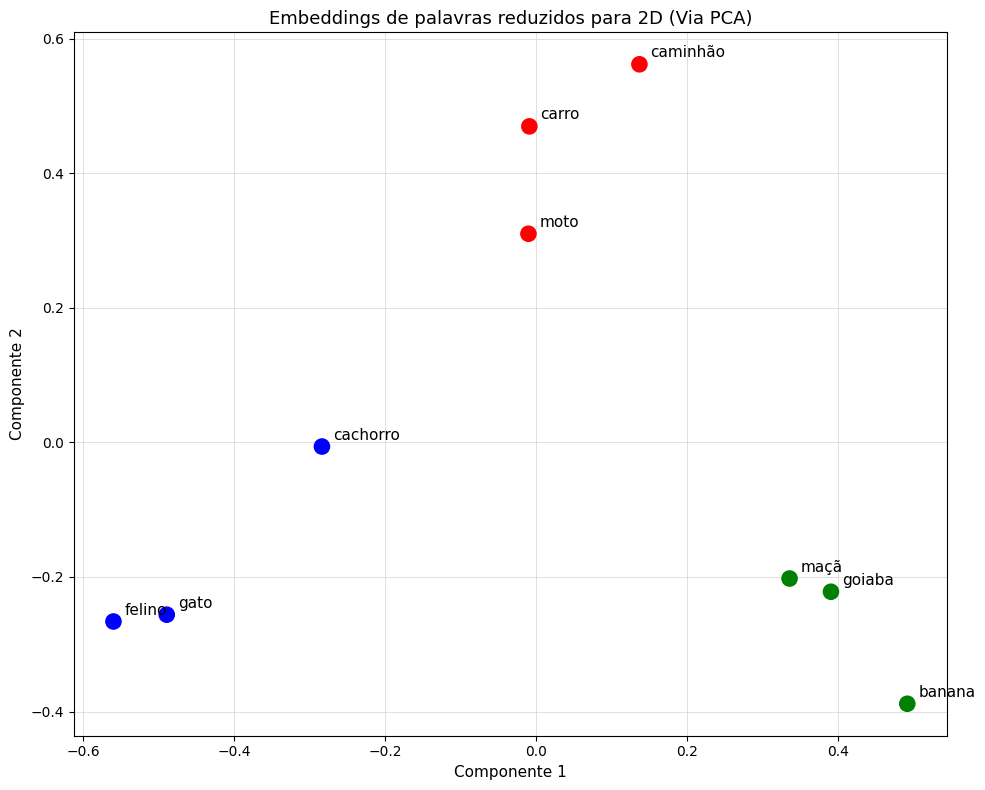

In [36]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from google.colab import userdata

OPENROUTER_API_KEY = userdata.get('OPENROUTER_API_KEY')

categorias = {
    "gato": "blue", "felino": "blue", "cachorro": "blue",
    "carro": "red", "caminhão": "red", "moto": "red",
    "banana": "green", "maçã": "green", "goiaba": "green"
}

palavras = list(categorias.keys())
cores = list(categorias.values())

def gerar_dicionario_embeddings(lista_palavras):
    response = requests.post(
        "https://openrouter.ai/api/v1/embeddings",
        headers={
            "Authorization": f"Bearer {OPENROUTER_API_KEY}",
            "Content-Type": "application/json",
        },
        json={
            "model": "openai/text-embedding-3-small",
            "input": lista_palavras
        }
    )

    response.raise_for_status()
    data = response.json()

    embeddings_dict = {}
    for item, palavra in zip(data["data"], lista_palavras):
        embeddings_dict[palavra] = np.array(item["embedding"])

    return embeddings_dict

embeddings_db = gerar_dicionario_embeddings(palavras)

matriz_embeddings = np.array([embeddings_db[p] for p in palavras])

pca = PCA(n_components=2)
coords_2d = pca.fit_transform(matriz_embeddings)

plt.figure(figsize=(10, 8))
plt.grid(True, linestyle='-', linewidth=0.5, color='lightgray', zorder=0)

plt.scatter(coords_2d[:, 0], coords_2d[:, 1], c=cores, s=120, zorder=3)

for i, palavra in enumerate(palavras):
    plt.annotate(
        palavra,
        (coords_2d[i, 0], coords_2d[i, 1]),
        textcoords="offset points",
        xytext=(8, 5),
        fontsize=11,
        zorder=4
    )

plt.title("Embeddings de palavras reduzidos para 2D (Via PCA)", fontsize=13)
plt.xlabel("Componente 1", fontsize=11)
plt.ylabel("Componente 2", fontsize=11)

plt.tight_layout()
plt.show()

In [38]:
import requests
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA
from google.colab import userdata

OPENROUTER_API_KEY = userdata.get('OPENROUTER_API_KEY')

categorias_map = {
    "gato": "Animais", "felino": "Animais", "cachorro": "Animais",
    "carro": "Veículos", "caminhão": "Veículos", "moto": "Veículos",
    "banana": "Frutas", "maçã": "Frutas", "goiaba": "Frutas"
}

palavras = list(categorias_map.keys())

def gerar_embeddings(lista_palavras):
    print("Buscando embeddings na API... (isso pode levar alguns segundos)")
    response = requests.post(
        "https://openrouter.ai/api/v1/embeddings",
        headers={
            "Authorization": f"Bearer {OPENROUTER_API_KEY}",
            "Content-Type": "application/json",
        },
        json={
            "model": "openai/text-embedding-3-small",
            "input": lista_palavras
        }
    )
    response.raise_for_status()
    data = response.json()
    return np.array([item["embedding"] for item in data["data"]])

matriz_embeddings = gerar_embeddings(palavras)

pca = PCA(n_components=3)
coords_3d = pca.fit_transform(matriz_embeddings)

df_plot = pd.DataFrame({
    'Palavra': palavras,
    'X': coords_3d[:, 0],
    'Y': coords_3d[:, 1],
    'Z': coords_3d[:, 2],
    'Categoria': [categorias_map[p] for p in palavras]
})


fig = px.scatter_3d(
    df_plot,
    x='X', y='Y', z='Z',
    color='Categoria',
    text='Palavra',
    title="Visualização 3D Interativa de Embeddings",
    color_discrete_map={
        "Animais": "blue",
        "Veículos": "red",
        "Frutas": "green"
    }
)

fig.update_traces(
    marker=dict(size=8, opacity=0.8),
    textposition='top center'
)

fig.show()

Buscando embeddings na API... (isso pode levar alguns segundos)
